In [1]:
import os 
import operator 

from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_tavily import TavilySearch
from langgraph.prebuilt import ToolNode, tools_condition

In [2]:
load_dotenv()

model1 = init_chat_model(model='gemini-2.5-flash-lite', api_key=os.getenv("GEMINI_API_KEY"), model_provider="google_genai")

In [3]:
web_search_tool = TavilySearch(max_results=2)
tools = [web_search_tool]
llm_with_tools = model1.bind_tools(tools)

### **News Reader online**

In [4]:
class NewsState(TypedDict):
    messages: Annotated[list, add_messages]
    iteration: int
    approve_status: Literal['approved', 'not_approved']
    feedback: str

class Evaluation(BaseModel):
    approve : Literal['approved', 'not_approved'] = Field(description="Final evaluation result")
    feedback: str = Field(description="feedback for the AI result and tell what should be the improvement")

In [5]:
evaluator_llm = model1.with_structured_output(Evaluation)

In [6]:
def chatnode(state: NewsState):
    message = state['messages']
    iteration = state['iteration'] + 1 

    response = llm_with_tools.invoke(message)

    return {"messages": [response], "iteration": iteration}


tool_node = ToolNode(tools=[web_search_tool])

def evaluator_node(state: NewsState):
    message = state['messages']

    prompt = f"Analysis this conversation : {message}. If the AI answer perfectly then approve it other wise don't approve. You should need to give a feedback."

    response = evaluator_llm.invoke(prompt)

    return {"feedback": response.feedback, "approve_status": response.approve}



In [7]:
def evaluation_condition(state: NewsState):
    if state['approve_status'] == "approved" or state['iteration']>=5: return "approved"
    else: return "not_approved"

## Simple Tool calling example

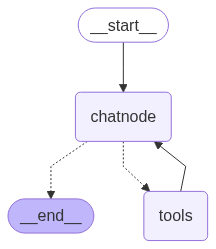

In [11]:
graph = StateGraph(NewsState)

graph.add_node("chatnode", chatnode)
graph.add_node("tools", tool_node) 

graph.add_edge(START, "chatnode")
graph.add_conditional_edges("chatnode", tools_condition)
graph.add_edge("tools", "chatnode")
graph.add_edge("chatnode", END)

chatbot= graph.compile()

chatbot

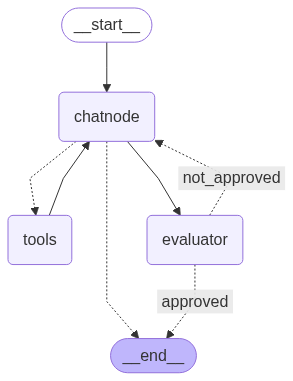

In [19]:
graph = StateGraph(NewsState)

graph.add_node("chatnode", chatnode)
graph.add_node("tools", tool_node) 
graph.add_node("evaluator", evaluator_node)

graph.add_edge(START, "chatnode")
graph.add_conditional_edges("chatnode", tools_condition)
graph.add_edge("tools", "chatnode")
graph.add_edge("chatnode", "evaluator")
graph.add_conditional_edges("evaluator", evaluation_condition,{"approved":END, "not_approved": "chatnode"})

graph.add_edge("chatnode", END)

workflow = graph.compile()

workflow

In [20]:
message = {"messages": ["Tell me who is the president of USA right now?"], "iteration": 1}

response = workflow.invoke(message)

response

Gemini produced an empty response. Continuing with empty message
Feedback: 


{'messages': [HumanMessage(content='Tell me who is the president of USA right now?', additional_kwargs={}, response_metadata={}, id='a6fd3473-46cb-4940-9da0-bd9f66bb9b4c'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "who is the president of USA right now"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': []}, id='run--d14df6a5-4874-406b-9baa-0cac11edbfbf-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'who is the president of USA right now'}, 'id': '03052d9e-0c11-4ebb-87c4-b22cb52338ff', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1251, 'output_tokens': 24, 'total_tokens': 1275, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='{"query": "who is the president of USA right now", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://